In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week1/breast_cancer.csv')

# 확인
df


,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [2]:
y=df['label']
y.value_counts()  # Outcome 값이 0과 1로 각각 몇 개씩 있는지 개수 확인
y

,label
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [3]:
X=df.drop('label',axis=1)   #label 열을 제외한 나머지 입력 변수(특성)들을 X에 저장
X.head()                    # X의 상위 5개 행을 출력

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
from sklearn.model_selection import train_test_split  # 데이터를 학습용/테스트용으로 나누는 함수 불러오기

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)  # 데이터를 75%를 학습용 25%를 테스트용으로 나눔 난수를 0으로하여 시드 고정

In [5]:
from sklearn.metrics import accuracy_score              # 정확도 평가 함수 불러오기
from sklearn.metrics import confusion_matrix            # 혼동행렬 평가 함수 불러오기


In [6]:
from sklearn.linear_model import LogisticRegression     # LogisticRegression(분류) 모델 불러오기

clf_lr = LogisticRegression(random_state=0, max_iter=5000)  # LogisticRegression 모델 생성
# 모델이 학습 도중 100번 안에 최적값을 찾지 못할 수 있어서 반복 횟수를 5000으로 늘림
clf_lr.fit(X_train, y_train)    # 학습용 데이터로 모델 학습

pred_lr = clf_lr.predict(X_test)    #결과 예측

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))               #정확도 출력
print (confusion_matrix(y_test, pred_lr))             #혼동행렬 출력


--- Logistic Regression Classifier ---
0.965034965034965
[[52  1]
 [ 4 86]]


In [7]:
from sklearn.tree import DecisionTreeClassifier      # DecisionTreeClassifier(분류) 모델 불러오기

clf_DT = DecisionTreeClassifier(random_state=0)       #  DecisionTreeClassifier 모델 생성
clf_DT.fit(X_train, y_train)                          # 학습용 데이터로 모델 학습

pred_DT = clf_DT.predict(X_test)                      #결과 예측

print ("\n--- DecisionTreeClassifier ---")
print (accuracy_score(y_test, pred_DT))               #정확도 출력
print (confusion_matrix(y_test, pred_DT))             #혼동행렬 출력


--- DecisionTreeClassifier ---
0.8951048951048951
[[49  4]
 [11 79]]


In [8]:
from sklearn.ensemble import RandomForestClassifier   # RandomForestClassifier(분류) 모델 불러오기


clf_RF = RandomForestClassifier(random_state=0)     #  RandomForestClassifier 모델 생성
clf_RF.fit(X_train, y_train)                        # 학습용 데이터로 모델 학습

pred_RF = clf_RF.predict(X_test)                     #결과 예측

print ("\n--- RandomForestClassifier ---")
print (accuracy_score(y_test, pred_RF))               #정확도 출력
print (confusion_matrix(y_test, pred_RF))             #혼동행렬 출력


--- RandomForestClassifier ---
0.9790209790209791
[[52  1]
 [ 2 88]]


In [9]:
from sklearn.neighbors import KNeighborsClassifier

clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(X_train, y_train)

pred_knn = clf_knn.predict(X_test)

print ("\n--- KNeighborsClassifier ---")
print (accuracy_score(y_test, pred_knn))
print (confusion_matrix(y_test, pred_knn))


--- KNeighborsClassifier ---
0.916083916083916
[[46  7]
 [ 5 85]]


In [10]:
# K값의 최적값을 찾기 위해 for문을 1~30까지 돌리고 그래프로 표현 Classifier에선 정확도가 가장 큰 값


--- KNeighborsClassifier 최적화 결과 ---
최적의 k: 4
최고 정확도: 0.9300699300699301

--- KNeighborsClassifier ---
정확도: 0.9300699300699301
혼동행렬:
 [[48  5]
 [ 5 85]]


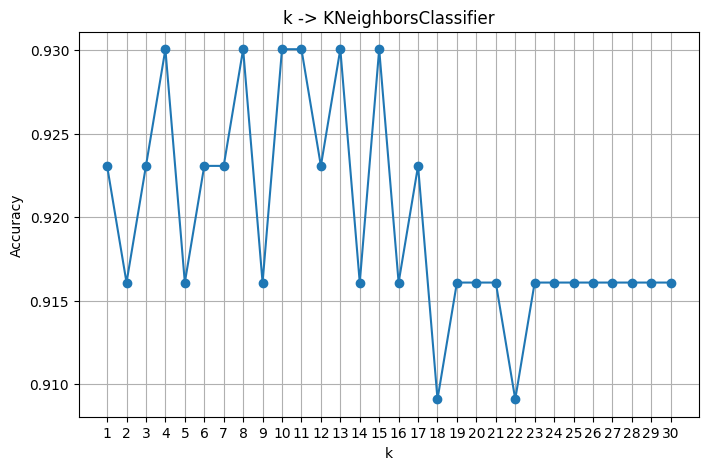

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

k_list = []
acc_list = []

#최적 k 찾기
for k in range(1, 31):
    clf_knn = KNeighborsClassifier(n_neighbors=k)
    clf_knn.fit(X_train, y_train)

    pred_knn = clf_knn.predict(X_test)

    acc = accuracy_score(y_test, pred_knn)

    k_list.append(k)
    acc_list.append(acc)

best_k = k_list[np.argmax(acc_list)]
best_acc = max(acc_list)

print("\n--- KNeighborsClassifier 최적화 결과 ---")
print("최적의 k:", best_k)
print("최고 정확도:", best_acc)

# 최적 k로 다시 학습
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)
pred_knn = best_model.predict(X_test)

print("\n--- KNeighborsClassifier ---")
print("정확도:", accuracy_score(y_test, pred_knn))
print("혼동행렬:\n", confusion_matrix(y_test, pred_knn))

# 그래프
plt.figure(figsize=(8, 5))
plt.plot(k_list, acc_list, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("k -> KNeighborsClassifier")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()